# Adult Income
Data Analysis - ISAE 2025/2026

In [57]:
if "google.colab" in str(get_ipython()):
    !curl -O https://raw.githubusercontent.com/PetitMalo/BE_data_analysis/main/bootstrap.py && python3 bootstrap.py

In [58]:
import os

import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from src.hyper_param_search import find_dtc_hyperparams, find_svm_hyperparams
from src.utils import get_latest_hyperparams, logger, metrics_classifier, predict_classifier

SEED = 42

In [59]:
data_path = "./data/"
data_file = os.path.join(data_path, "adult_sample.csv")
logger.info(f"Loading data from {data_file}")

2026-02-18 17:26:58.848 | INFO     | __main__:<module>:3 - Loading data from ./data/adult_sample.csv


## 1 - Data import

In [60]:
# Load data and labels
df = pd.read_csv(
    data_file,
    header=None,
    names=[
        "age",
        "workclass",
        "education",
        "education-num",
        "occupation",
        "relationship",
        "race",
        "sex",
        "capital-gain",
        "capital-loss",
        "hours-per-week",
        "native-country",
        "income",
    ],
)
df.sample(10)  # Let's take a random sample from the full data frame

,age,workclass,education,education-num,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
1143,45.0,Private,Some-college,10,Craft-repair,Husband,White,Male,0.0,0,40,United-States,<=50K
1038,34.0,Private,Bachelors,13,Sales,Husband,White,Male,15024.0,0,40,United-States,>50K
48,32.0,Private,HS-grad,9,Adm-clerical,Unmarried,White,Male,3887.0,0,40,United-States,<=50K
1958,38.0,Private,Some-college,10,Exec-managerial,Husband,White,Male,0.0,0,55,United-States,<=50K
1944,50.0,Private,HS-grad,9,Craft-repair,Husband,White,Male,5013.0,0,45,United-States,<=50K
561,38.0,Private,9th,5,Farming-fishing,Husband,White,Male,0.0,0,54,Mexico,<=50K
633,63.0,Local-gov,HS-grad,9,Exec-managerial,Wife,White,Female,0.0,0,32,United-States,<=50K
1379,33.0,NaN,Bachelors,13,NaN,Own-child,Asian-Pac-Islander,Male,0.0,0,80,Philippines,<=50K
524,26.0,Private,Some-college,10,Exec-managerial,Own-child,Black,Female,0.0,0,40,United-States,<=50K
1195,25.0,Private,Assoc-acdm,12,Tech-support,Own-child,White,Female,0.0,1594,25,United-States,<=50K


## 2 - Data analysis

In [61]:
df.info()  # quick information concerning the dataframe

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1967 entries, 0 to 1966
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             1917 non-null   float64
 1   workclass       1842 non-null   object 
 2   education       1967 non-null   object 
 3   education-num   1967 non-null   int64  
 4   occupation      1842 non-null   object 
 5   relationship    1967 non-null   object 
 6   race            1967 non-null   object 
 7   sex             1967 non-null   object 
 8   capital-gain    1932 non-null   float64
 9   capital-loss    1967 non-null   int64  
 10  hours-per-week  1967 non-null   int64  
 11  native-country  1967 non-null   object 
 12  income          1967 non-null   object 
dtypes: float64(2), int64(3), object(8)
memory usage: 199.9+ KB


In [62]:
df = df.rename(columns=lambda x: x.strip().replace(" ", "_").lower())
numerical_features = [col for col in df.columns if df[col].dtype in ["int64", "float64"]]
categorical_features = [col for col in df.columns if col not in numerical_features]
logger.info(f"Numerical features: {numerical_features}")
logger.info(f"Categorical features: {categorical_features}")

# One-hot encode categorical features
logger.info("One-hot encoding categorical features")
encoder = OneHotEncoder(handle_unknown="ignore", drop="if_binary")
categorical_encoded = encoder.fit_transform(df[categorical_features])
categorical_cols = encoder.get_feature_names_out(categorical_features)
categorical_cols = [col.strip().lower().replace(" ", "") for col in categorical_cols]
categorical_encoded_df = pd.DataFrame(categorical_encoded.toarray(), columns=categorical_cols)
enumerated_cat_cols = zip(range(len(categorical_cols)), categorical_cols)
logger.info(f"Categorical features encoded: {list(enumerated_cat_cols)}")

# Scale numerical features
logger.info("Scaling numerical features")
scaler = StandardScaler()
numerical_scaled = scaler.fit_transform(df[numerical_features])

# Combine numerical and encoded categorical features
df_processed = pd.concat(
    [
        pd.DataFrame(numerical_scaled, columns=numerical_features).reset_index(drop=True),
        categorical_encoded_df.reset_index(drop=True),
    ],
    axis=1,
)
df_processed["income_>50k"] = df_processed["income_>50k"].apply(lambda x: int(x))
logger.info(f"Processed DataFrame from shape {df.shape}, to shape {df_processed.shape}")

2026-02-18 17:26:58.945 | INFO     | __main__:<module>:4 - Numerical features: ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
2026-02-18 17:26:58.946 | INFO     | __main__:<module>:5 - Categorical features: ['workclass', 'education', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'income']
2026-02-18 17:26:58.948 | INFO     | __main__:<module>:8 - One-hot encoding categorical features
2026-02-18 17:26:58.963 | INFO     | __main__:<module>:15 - Categorical features encoded: [(0, 'workclass_federal-gov'), (1, 'workclass_local-gov'), (2, 'workclass_private'), (3, 'workclass_self-emp-inc'), (4, 'workclass_self-emp-not-inc'), (5, 'workclass_state-gov'), (6, 'workclass_without-pay'), (7, 'workclass_nan'), (8, 'education_10th'), (9, 'education_11th'), (10, 'education_12th'), (11, 'education_1st-4th'), (12, 'education_5th-6th'), (13, 'education_7th-8th'), (14, 'education_9th'), (15, 'education_assoc-acdm'), (16, 'education_assoc-voc'), (17, 'educatio

In [63]:
# Show NaNs info
df_nan = df_processed[df_processed.isna().any(axis=1)]
nan_count = df_processed.isna().sum().sum()
logger.info(f"There are {nan_count} NaN values in the processed DataFrame.")
df_processed = df_processed.dropna(axis=0)
df_nan.head()

2026-02-18 17:26:58.989 | INFO     | __main__:<module>:4 - There are 85 NaN values in the processed DataFrame.


,age,education-num,capital-gain,capital-loss,hours-per-week,workclass_federal-gov,workclass_local-gov,workclass_private,workclass_self-emp-inc,workclass_self-emp-not-inc,...,native-country_philippines,native-country_poland,native-country_portugal,native-country_puerto-rico,native-country_scotland,native-country_south,native-country_taiwan,native-country_united-states,native-country_vietnam,income_>50k
6,NaN,-1.158607,-0.125264,-0.217189,-0.001465,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0
13,2.544550,1.259409,NaN,-0.217189,-0.801997,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0
16,0.960605,1.662412,NaN,-0.217189,0.799067,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1
76,NaN,-3.576624,-0.125264,-0.217189,-0.001465,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
82,1.536585,-0.352602,NaN,-0.217189,-1.922742,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0


In [64]:
df_processed.describe()

,age,education-num,capital-gain,capital-loss,hours-per-week,workclass_federal-gov,workclass_local-gov,workclass_private,workclass_self-emp-inc,workclass_self-emp-not-inc,...,native-country_philippines,native-country_poland,native-country_portugal,native-country_puerto-rico,native-country_scotland,native-country_south,native-country_taiwan,native-country_united-states,native-country_vietnam,income_>50k
count,1885.000000,1885.000000,1885.000000,1885.000000,1885.000000,1885.000000,1885.000000,1885.000000,1885.000000,1885.000000,...,1885.000000,1885.000000,1885.000000,1885.000000,1885.000000,1885.000000,1885.000000,1885.000000,1885.000000,1885.000000
mean,0.001682,0.000587,-0.007487,0.005013,0.001762,0.024934,0.066313,0.707692,0.023342,0.076393,...,0.007427,0.002653,0.002653,0.002653,0.000531,0.001592,0.001061,0.903448,0.001592,0.151194
std,0.999477,0.997584,0.922064,1.012596,1.004834,0.155964,0.248894,0.454944,0.151028,0.265696,...,0.085883,0.051448,0.051448,0.051448,0.023033,0.039873,0.032564,0.295425,0.039873,0.358333
min,-1.487310,-3.576624,-0.125264,-0.217189,-2.963434,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-0.839332,-0.352602,-0.125264,-0.217189,-0.161572,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
50%,-0.191355,0.050401,-0.125264,-0.217189,-0.001465,0.000000,0.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,0.672615,0.453404,-0.125264,-0.217189,0.318748,0.000000,0.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
max,3.768507,2.468417,18.111017,6.081703,4.721674,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


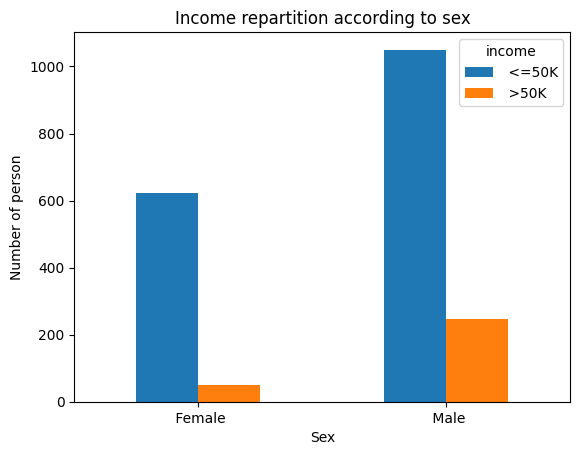

In [65]:
# Let's analyze one feature (sex) according to the label (income)
counts = df.groupby(["sex", "income"]).size().unstack()

# Let's display the graphic
counts.plot(kind="bar", stacked=False)
plt.title("Income repartition according to sex")
plt.ylabel("Number of person")
plt.xlabel("Sex")
plt.xticks(rotation=0)
plt.show()

2026-02-18 17:26:59.599 | INFO     | __main__:<module>:4 - Explained variance ratio: [0.16406781 0.12178865]
2026-02-18 17:26:59.600 | INFO     | __main__:<module>:5 - Singular values: [51.15596068 44.07455851]


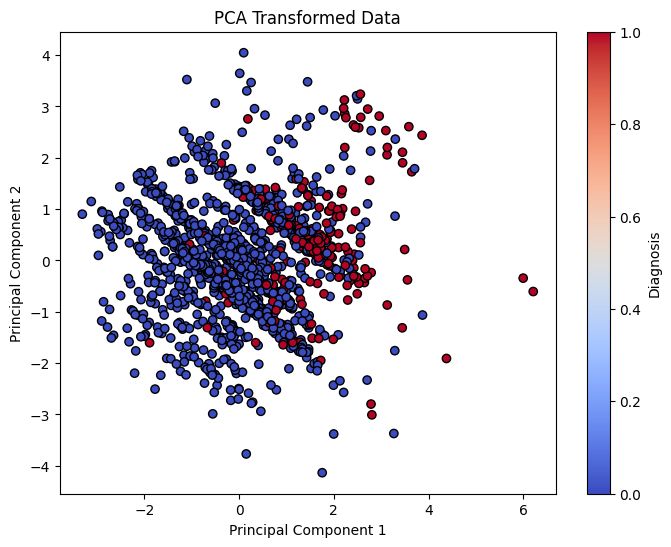

In [66]:
X = df_processed.drop(columns=["income_>50k"]).to_numpy()
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
logger.info(f"Explained variance ratio: {pca.explained_variance_ratio_}")
logger.info(f"Singular values: {pca.singular_values_}")

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df_processed["income_>50k"], cmap="coolwarm", edgecolor="k")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Transformed Data")
plt.colorbar(label="Diagnosis")
plt.show()

In [67]:
tsne = TSNE(n_components=2, random_state=SEED)
X = df_processed.drop(columns=["income_>50k"]).to_numpy()
y = df_processed["income_>50k"].to_numpy(dtype=int)
X_tsne = tsne.fit_transform(X)
fig = px.scatter(x=X_tsne[:, 0], y=X_tsne[:, 1], color=y)
fig.update_layout(
    title="t-SNE visualization of adult income dataset",
    xaxis_title="First t-SNE",
    yaxis_title="Second t-SNE",
)
fig.show()

In [68]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y
)

## 3 - Models

### 3.1 - Decision Tree Classifier

In [69]:
search_dtc_best_params = False
if search_dtc_best_params:
    logger.info("Searching for optimal hyperparameters...")
    dtc_hyper_params = find_dtc_hyperparams(X_train, y_train, metric="f1")
    logger.info(f"Optimal hyperparameters found: {dtc_hyper_params}")

In [70]:
try:
    logger.info("Best hyperparameters:")
    logger.info(dtc_hyper_params)
except NameError:
    hyper_param_path = "./models/dtc_best_hyperparams.json"
    dtc_hyper_params = get_latest_hyperparams(prefix="dtc_best_hyperparams")
    logger.info(f"Using previously found hyperparameters from: {hyper_param_path}")
    logger.info(dtc_hyper_params)

dtf = DecisionTreeClassifier(**dtc_hyper_params, random_state=SEED)
dtf.fit(X_train, y_train)
accuracy = dtf.score(X_test, y_test)
logger.info(f"Decision Tree Classifier accuracy: {accuracy:.4f}")

2026-02-18 17:27:09.073 | INFO     | __main__:<module>:2 - Best hyperparameters:
2026-02-18 17:27:09.074 | INFO     | __main__:<module>:3 - {'max_depth': 236, 'min_samples_split': 16, 'min_samples_leaf': 1, 'criterion': 'gini'}
2026-02-18 17:27:09.085 | INFO     | __main__:<module>:13 - Decision Tree Classifier accuracy: 0.8559


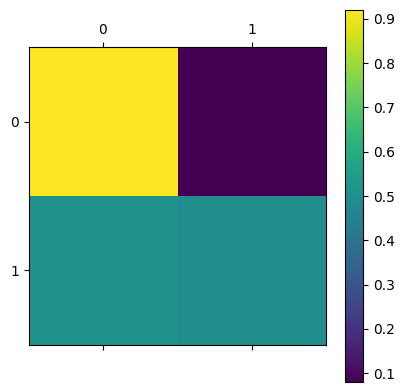

Accuracy: 70.66%
Precision: 75.27%
Recall: 70.66%
F1-score: 72.89%
Decision Tree confusion matrix:
[[0.9201995  0.0798005 ]
 [0.50704225 0.49295775]]
Decision Tree metrics:


In [71]:
cm_test = predict_classifier(classifier=dtf, x_data=X_test, y_true=y_test, plot_cm=True)
results_dtf = metrics_classifier(cm=cm_test, plot=True)
print("Decision Tree confusion matrix:")
print(cm_test)
print("Decision Tree metrics:")

### 3.2 - SVM

In [72]:
search_svm_best_params = False
if search_svm_best_params:
    logger.info("Searching for optimal hyperparameters...")
    svm_hyper_params = find_svm_hyperparams(X_train, y_train, metric="f1")
    logger.info(f"Optimal hyperparameters found: {svm_hyper_params}")

In [73]:
try:
    logger.info("Best hyperparameters:")
    logger.info(svm_hyper_params)
except NameError:
    hyper_param_path = "./models/svm_best_hyperparams.json"
    svm_hyper_params = get_latest_hyperparams(prefix="svm_best_hyperparams")
    logger.info(f"Using previously found hyperparameters from: {hyper_param_path}")
    logger.info(svm_hyper_params)

svc = SVC(**svm_hyper_params, random_state=SEED)
svc.fit(X_train, y_train)
accuracy = svc.score(X_test, y_test)
logger.info(f"Support Vector Machine accuracy: {accuracy:.4f}")

2026-02-18 17:27:09.308 | INFO     | __main__:<module>:2 - Best hyperparameters:
2026-02-18 17:27:09.309 | INFO     | __main__:<module>:3 - {'C': 116.35880999575085, 'gamma': 0.008762067530603934, 'kernel': 'rbf'}
2026-02-18 17:27:09.421 | INFO     | __main__:<module>:13 - Support Vector Machine accuracy: 0.8856


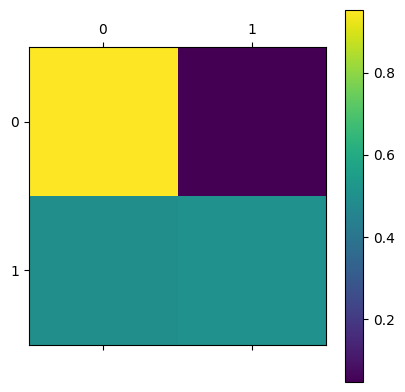

Support Vector Machine confusion matrix:
[[0.95261845 0.04738155]
 [0.49295775 0.50704225]]
Support Vector Machine metrics:
Accuracy: 72.98%
Precision: 78.68%
Recall: 72.98%
F1-score: 75.72%


In [74]:
cm_test = predict_classifier(classifier=svc, x_data=X_test, y_true=y_test, plot_cm=True)
print("Support Vector Machine confusion matrix:")
print(cm_test)
print("Support Vector Machine metrics:")
results_svc = metrics_classifier(cm=cm_test, plot=True)